# Visualize `target_world_pos` — rendered with the robot
Patches a mocap sphere into the XML so you can see the red target ball rendered with the actual robot mesh.

In [1]:
import os
os.environ['MUJOCO_GL'] = 'egl'

In [2]:
import tempfile, os
import numpy as np
import mujoco
import matplotlib.pyplot as plt

XML_PATH = "robot_model/pupper_v3.xml"   # adjust path if needed

with open(XML_PATH) as f:
    xml_text = f.read()

# Inject a mocap body (red sphere) just before </worldbody>.
# mocap="true" means we can move it freely via mj_data.mocap_pos.
MOCAP_BODY = """
    <body name="target_marker" mocap="true" pos="0 0 0">
      <geom type="sphere" size="0.01" rgba="1 0 0 0.85" contype="0" conaffinity="0" group="1"/>
    </body>
"""
xml_patched = xml_text.replace("</worldbody>", MOCAP_BODY + "</worldbody>")

# Write to same directory as the XML so the meshdir resolves correctly
xml_dir = os.path.dirname(os.path.abspath(XML_PATH))
with tempfile.NamedTemporaryFile(suffix='.xml', delete=False, mode='w', dir=xml_dir) as tmp:
    tmp.write(xml_patched)
    tmp_path = tmp.name

mj_model = mujoco.MjModel.from_xml_path(tmp_path)
mj_data  = mujoco.MjData(mj_model)
os.unlink(tmp_path)
print("Model loaded OK")

Model loaded OK


In [3]:
# ── Site ids (same order as environment.py) ────────────────────────────────────
FOOT_SITE_NAMES = [
    "leg_front_r_3_foot_site",   # index 0 → foot_idx=0 (right)
    "leg_front_l_3_foot_site",   # index 1 → foot_idx=1 (left)
    "leg_back_r_3_foot_site",
    "leg_back_l_3_foot_site",
]
foot_site_ids = np.array([
    mujoco.mj_name2id(mj_model, mujoco.mjtObj.mjOBJ_SITE, n) for n in FOOT_SITE_NAMES
])

torso_body_id = mujoco.mj_name2id(mj_model, mujoco.mjtObj.mjOBJ_BODY, "base_link")
mocap_body_id = mujoco.mj_name2id(mj_model, mujoco.mjtObj.mjOBJ_BODY, "target_marker")
mocap_data_id = mj_model.body_mocapid[mocap_body_id]  # index into mocap_pos array

def quat_rotate(v, q):
    """Rotate vector v by quaternion q=[w,x,y,z] — same as brax.math.rotate."""
    w, x, y, z = q
    t = 2.0 * np.cross([x, y, z], v)
    return v + w * t + np.cross([x, y, z], t)

def compute_target_world_pos(cmd):
    """
    Mirrors step() in environment.py:
      leg_idx    = cmd[3]
      anchor_idx = 1 - leg_idx          # stance foot
      anchor_world = site_xpos[feet_site_ids[anchor_idx]]
      target_world  = anchor_world + rotate(cmd[:3], torso_quat)
    """
    target_local = cmd[:3]
    foot_idx      = int(cmd[3])
    anchor_idx    = 1 - foot_idx

    anchor_world = mj_data.site_xpos[foot_site_ids[anchor_idx]].copy()
    torso_quat   = mj_data.xquat[torso_body_id].copy()   # [w, x, y, z]

    target_world = anchor_world + quat_rotate(target_local, torso_quat)
    return target_world, anchor_world, foot_idx

In [40]:
# 1. Renamed to box_bounds so it doesn't conflict!
box_bounds = [(0.05, 0.2), (0.05, 0.25), (-0.05, 0.075)]

def render(cmd, width=640, height=480, camera="tracking_cam"):
    mujoco.mj_resetDataKeyframe(mj_model, mj_data, 0)
    mujoco.mj_fwdPosition(mj_model, mj_data)

    target_world, anchor_world, foot_idx = compute_target_world_pos(cmd)

    # Place mocap sphere
    mj_data.mocap_pos[mocap_data_id] = target_world
    mujoco.mj_forward(mj_model, mj_data)

    # NOTE: EVERYTHING below is indented INSIDE the `with` block!
    with mujoco.Renderer(mj_model, height=height, width=width) as renderer:
        # 1. Update the visual scene normally
        renderer.update_scene(mj_data, camera=camera)

        # --- DYNAMIC BOUNDING BOX INJECTION ---
        # 2. Calculate local center using box_bounds
        x_center = (box_bounds[0][1] + box_bounds[0][0]) / 2.0
        y_center = ((box_bounds[1][1] + box_bounds[1][0]) / 2.0) * ( (foot_idx * 2.0) - 1.0) # Flip Y based on foot
        z_center = (box_bounds[2][1] + box_bounds[2][0]) / 2.0
        local_center = np.array([x_center, y_center, z_center])
        
        # 3. Transform box center to world space
        torso_quat = mj_data.xquat[torso_body_id]
        box_center_world = anchor_world + quat_rotate(local_center, torso_quat)
        
        # 4. Calculate half-extents (size) for the MuJoCo box geom into a new variable
        geom_extents = np.array([
            (box_bounds[0][1] - box_bounds[0][0]) / 2.0,   # X half-width
            (box_bounds[1][1] - box_bounds[1][0]) / 2.0,   # Y half-width
            (box_bounds[2][1] - box_bounds[2][0]) / 2.0    # Z half-width
        ])
        
        # 5. Inject a translucent green box directly into the visual renderer
        mujoco.mjv_initGeom(
            renderer.scene.geoms[renderer.scene.ngeom],
            type=mujoco.mjtGeom.mjGEOM_BOX,
            size=geom_extents,
            pos=box_center_world,
            mat=mj_data.xmat[torso_body_id].flatten(), # Match robot's rotation
            rgba=np.array([0.0, 1.0, 0.0, 0.15])       # 15% opaque green
        )
        renderer.scene.ngeom += 1 # Tell the renderer we added 1 object
        # ----------------------------------------

        # 6. Render the frame (STILL INSIDE THE `WITH` BLOCK!)
        img = renderer.render()
        
    return img

In [21]:
def sample_random_command():
    """Generates a random target command using the exact bounding box logic."""
    # get which foot (0.0 or 1.0)
    foot_idx = float(np.random.choice([0, 1]))

    # define bounding box for target coordinates
    foot_y_abs_range = box_bounds[1] # absolute because it flips depending on foot
    foot_x_range = box_bounds[0]
    foot_z_range = box_bounds[2]

    # sample y pos and flip based on foot
    abs_y = np.random.uniform(foot_y_abs_range[0], foot_y_abs_range[1])
    y_sign = (foot_idx * 2.0) - 1.0
    t_y = abs_y * y_sign

    # sample x and z
    t_x = np.random.uniform(foot_x_range[0], foot_x_range[1])
    t_z = np.random.uniform(foot_z_range[0], foot_z_range[1])

    return np.array([t_x, t_y, t_z, foot_idx])


cmd: [0.15 0.12 0.05 0.  ]

cmd: [ 0.15 -0.12  0.05  1.  ]

cmd: [0.05 0.28 0.1  0.  ]

cmd: [ 0.22  0.08 -0.03  1.  ]


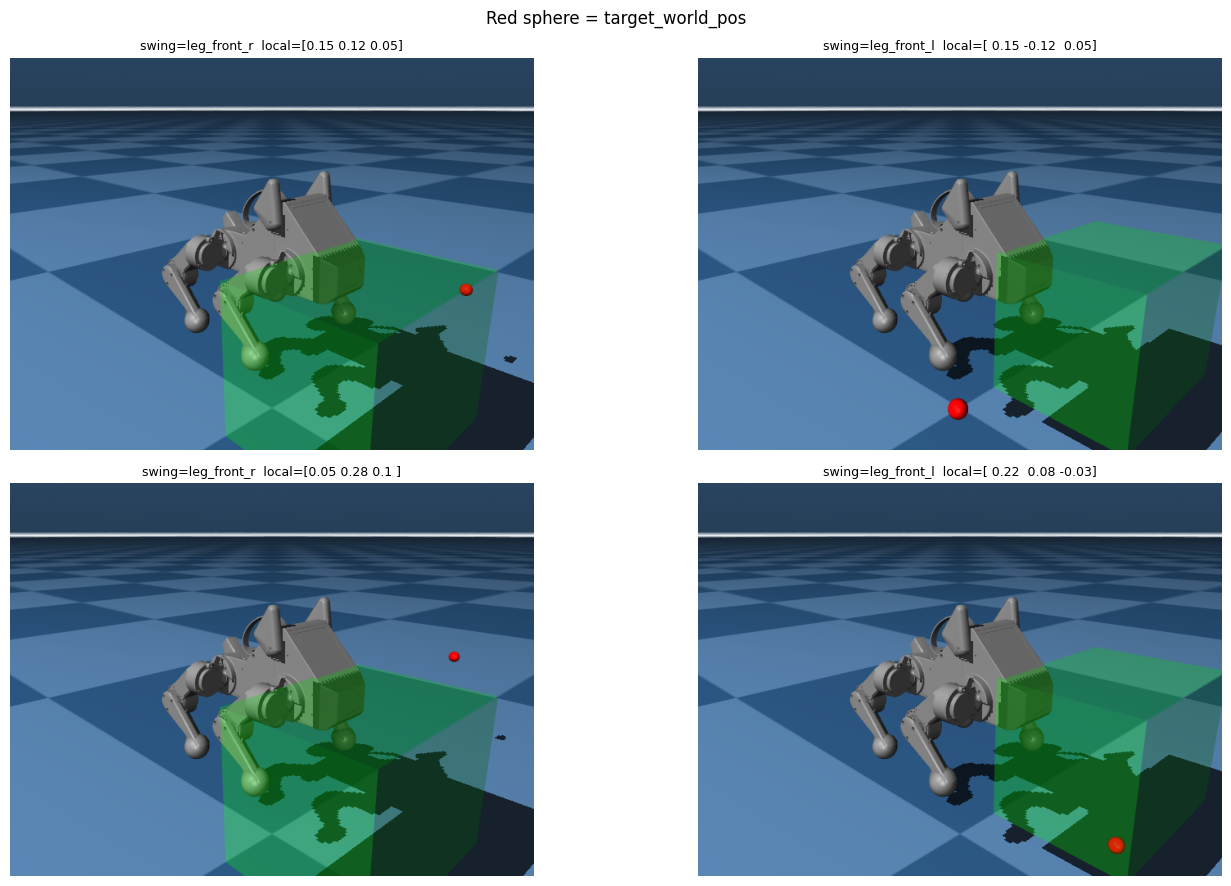

In [22]:
# ── Render a grid of test commands ────────────────────────────────────────────
# cmd = [t_x, t_y, t_z, foot_idx]   foot_idx: 0=front_r swing, 1=front_l swing
test_commands = [
    np.array([0.15,  0.12,  0.05, 0.0]),   # right swings, moderate forward
    np.array([0.15, -0.12,  0.05, 1.0]),   # left  swings, moderate forward
    np.array([0.05,  0.28,  0.10, 0.0]),   # right swings, far lateral
    np.array([0.22,  0.08, -0.03, 1.0]),   # left  swings, low target
]

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, cmd in zip(axes.flat, test_commands):
    print(f"\ncmd: {cmd}")
    img = render(cmd)
    foot_idx  = int(cmd[3])
    swing_name = FOOT_SITE_NAMES[foot_idx].replace("_3_foot_site", "")
    ax.imshow(img)
    ax.set_title(f"swing={swing_name}  local={np.round(cmd[:3], 2)}", fontsize=9)
    ax.axis('off')

plt.suptitle("Red sphere = target_world_pos", fontsize=12)
plt.tight_layout()
plt.show()

[ 0.08004017 -0.21767994 -0.0345009   0.        ]


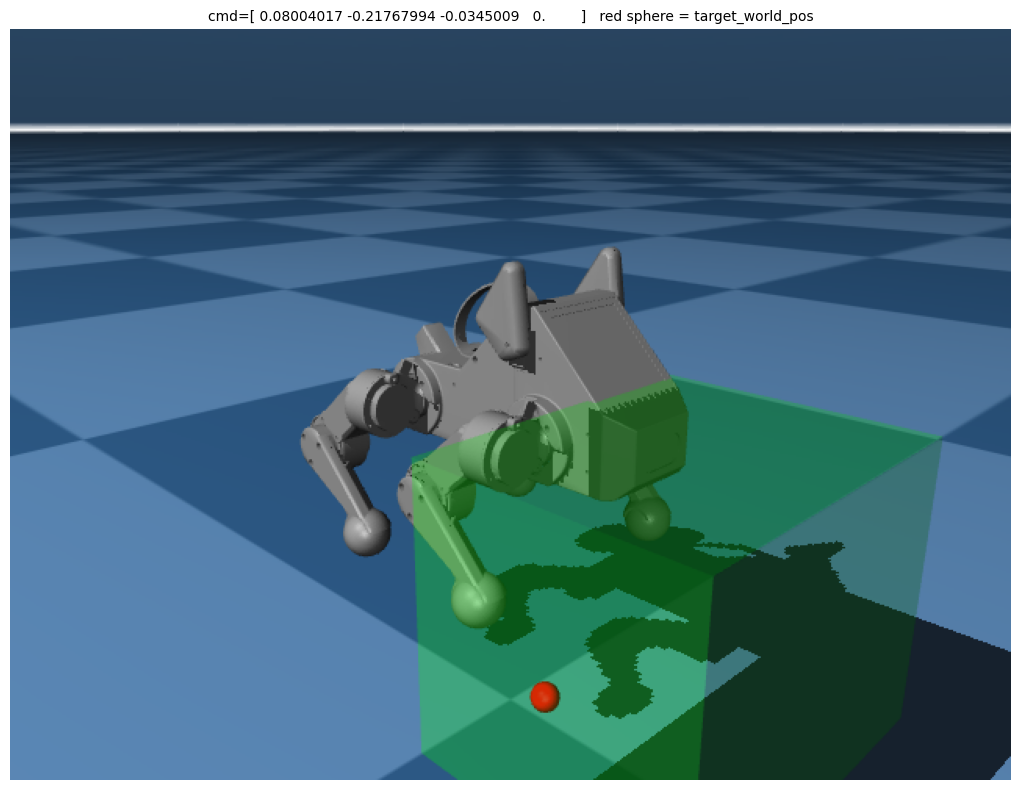

In [33]:
# ── Single command — edit and re-run this cell to inspect interactively ────────
my_cmd = sample_random_command()   # <-- change me
print(my_cmd)
img = render(my_cmd)
plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis('off')
plt.title(f"cmd={my_cmd}   red sphere = target_world_pos", fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import mujoco

# 1. Pose the robot and place the ghost sphere
cmd = sample_random_command()  
print("left" if cmd[3] == 1.0 else "right")
print(cmd)
mujoco.mj_resetDataKeyframe(mj_model, mj_data, 0)
mujoco.mj_fwdPosition(mj_model, mj_data)

target_world, anchor_world, foot_idx = compute_target_world_pos(cmd)
mj_data.mocap_pos[mocap_data_id] = target_world
mujoco.mj_forward(mj_model, mj_data)

# 2. Setup the Matplotlib figure for interactive updating
fig, ax = plt.subplots(figsize=(10, 6))
img_plot = ax.imshow(np.zeros((480, 640, 3), dtype=np.uint8))
ax.axis('off')
plt.close(fig)  

# Create a free-floating camera
camera = mujoco.MjvCamera()
mujoco.mjv_defaultCamera(camera)

# We added 'robot_yaw' to the arguments!
def interactive_view(azimuth, elevation, distance, robot_yaw):
    # 1. Reset to the default home pose
    mujoco.mj_resetDataKeyframe(mj_model, mj_data, 0)
    
    # 2. HACK THE ROBOT'S ROTATION IN QPOS
    yaw_rad = np.radians(robot_yaw)
    # A simple Z-axis rotation (Yaw) converted to a quaternion [w, x, y, z]
    mj_data.qpos[3:7] = [np.cos(yaw_rad / 2.0), 0.0, 0.0, np.sin(yaw_rad / 2.0)]
    
    # 3. Compute forward kinematics so the robot's body updates to the new rotation
    mujoco.mj_fwdPosition(mj_model, mj_data)

    # 4. NOW compute the target math (it will use the updated rotated torso!)
    target_world, anchor_world, foot_idx = compute_target_world_pos(cmd)
    mj_data.mocap_pos[mocap_data_id] = target_world
    mujoco.mj_forward(mj_model, mj_data)

    # 5. Update camera coordinates
    camera.azimuth = azimuth
    camera.elevation = elevation
    camera.distance = distance
    camera.lookat[:] = [0.0, 0.0, 0.15] 
    
    with mujoco.Renderer(mj_model) as renderer:
        # Render the base scene
        renderer.update_scene(mj_data, camera=camera)
        
        # --- DYNAMIC BOUNDING BOX INJECTION ---
        x_center = (box_bounds[0][1] + box_bounds[0][0]) / 2.0
        y_center = ((box_bounds[1][1] + box_bounds[1][0]) / 2.0) * ((foot_idx * 2.0) - 1.0)
        z_center = (box_bounds[2][1] + box_bounds[2][0]) / 2.0
        local_center = np.array([x_center, y_center, z_center])
        
        torso_quat = mj_data.xquat[torso_body_id]
        box_center_world = anchor_world + quat_rotate(local_center, torso_quat)
        
        geom_extents = np.array([
            (box_bounds[0][1] - box_bounds[0][0]) / 2.0,   
            (box_bounds[1][1] - box_bounds[1][0]) / 2.0,   
            (box_bounds[2][1] - box_bounds[2][0]) / 2.0    
        ])
        
        mujoco.mjv_initGeom(
            renderer.scene.geoms[renderer.scene.ngeom],
            type=mujoco.mjtGeom.mjGEOM_BOX,
            size=geom_extents,
            pos=box_center_world,
            mat=mj_data.xmat[torso_body_id].flatten(), # This ensures the box tilts/yaws with the robot!
            rgba=np.array([0.0, 1.0, 0.0, 0.15])       
        )
        renderer.scene.ngeom += 1 
        # ----------------------------------------
        
        img_plot.set_data(renderer.render())
        
    display(fig)

# 6. Launch the UI with the new Robot Yaw slider!
widgets.interact(
    interactive_view, 
    azimuth=widgets.IntSlider(value=90, min=0, max=360, step=5, description='Cam Spin'),
    elevation=widgets.IntSlider(value=-30, min=-90, max=0, step=5, description='Cam Tilt'),
    distance=widgets.FloatSlider(value=1.0, min=0.3, max=3.0, step=0.1, description='Cam Zoom'),
    robot_yaw=widgets.IntSlider(value=0, min=-180, max=180, step=15, description='Robot Yaw')
)

left
[0.06296701 0.08579655 0.03200329 1.        ]


interactive(children=(IntSlider(value=90, description='Cam Spin', max=360, step=5), IntSlider(value=-30, descr…

<function __main__.interactive_view(azimuth, elevation, distance, robot_yaw)>